In [ ]:
import pandas as pd

# Load data
df = pd.read_csv('/AB_Test_Results.csv')

# 1: Remove duplicates
df = df.drop_duplicates(subset='USER_ID')

# 2: Create a 'converted' column and preview the conversion rates
df['converted'] = df['REVENUE'] > 0
print(df.groupby('VARIANT_NAME')['converted'].mean())

VARIANT_NAME
control    0.015006
variant    0.013471
Name: converted, dtype: float64


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Prepare the numbers for the test
# Here We group the data and sum the 'converted' column (successes) and count the rows (totals)
group_results = df.groupby('VARIANT_NAME')['converted'].agg(['sum', 'count'])

successes = group_results['sum'].values
n_observations = group_results['count'].values

# 2. Run the Z-test
# This compares the 1.50% to the 1.34%
z_stat, p_value = proportions_ztest(successes, n_observations)

print(f"P-Value: {p_value:.4f}")

# 3. The Decision
if p_value < 0.05:
    print("Result: Statistically Significant. The difference is real!")
else:
    print("Result: Not Significant. The difference is likely just due to random chance.")

P-Value: 0.6063
Result: Not Significant. The difference is likely just due to random chance.


/tmp/ipykernel_5574/3151266493.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VARIANT_NAME', y='converted', data=df, capsize=.1, palette='coolwarm')


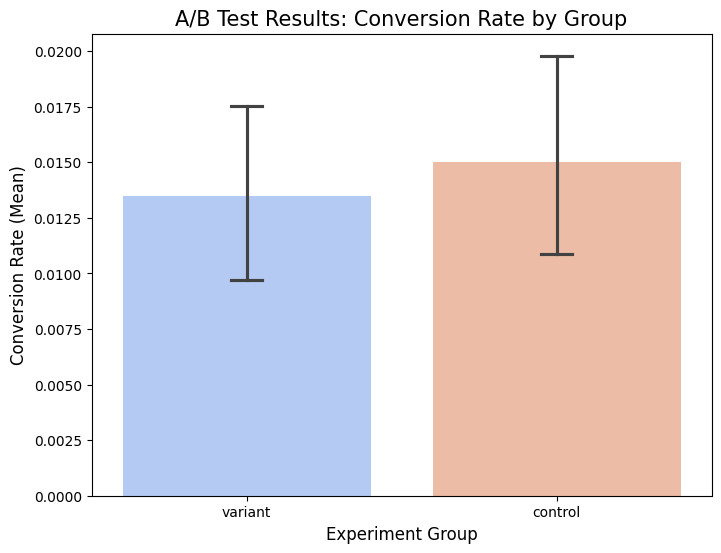

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(8, 6))
sns.barplot(x='VARIANT_NAME', y='converted', data=df, capsize=.1, palette='coolwarm')

# Add labels to make it professional
plt.title('A/B Test Results: Conversion Rate by Group', fontsize=15)
plt.ylabel('Conversion Rate (Mean)', fontsize=12)
plt.xlabel('Experiment Group', fontsize=12)

# Show the plot
plt.show()

In [ ]:
# Install pandasql if you haven't already
%pip install pandasql

In [ ]:
from pandasql import sqldf

# Define the SQL query
# We'll use AVG(CASE WHEN converted THEN 1 ELSE 0 END) to get the conversion rate
sql_query = """
SELECT
    VARIANT_NAME,
    AVG(CASE WHEN converted THEN 1 ELSE 0 END) AS conversion_rate
FROM
    df
GROUP BY
    VARIANT_NAME
"""

# Execute the SQL query on the pandas DataFrame 'df'
conversion_rates_sql = sqldf(sql_query, globals())

# Display the results
print("Conversion Rates (from SQL query):")
print(conversion_rates_sql)

Conversion Rates (from SQL query):
  VARIANT_NAME  conversion_rate
0      control         0.015006
1      variant         0.013471


This SQL query calculates the average conversion rate for each `VARIANT_NAME` (control and variant) directly from your `df` DataFrame. The `AVG(CASE WHEN converted THEN 1 ELSE 0 END)` part is a common SQL trick to calculate the mean of a boolean column, where `TRUE` is treated as 1 and `FALSE` as 0.